# **STUDENT NAME: M V K OM ADITYA**
## **ROLL NUMBER: 2025EM1300275**
### **COURSE: M.SC. DS & AI**

---



> **Chosen Dataset: Dataset 1: Diamonds Dataset**



> **Submission date: 08/08/2026**


---

[ Colab Link](https://colab.research.google.com/drive/1Lknzsw5Z5uHlKndx8tQ7XpOXK2PAeoTO?usp=sharing)




# Summary

This notebook analyzes the Seaborn Diamonds dataset to understand the factors that determine diamond prices and to develop a reliable predictive model. The dataset contains 53,940 observations and 10 variables, including carat, cut, color, clarity, depth, table, price, and the physical dimensions x, y, and z. The analysis began with descriptive statistics, distribution plots, categorical summaries, and correlation analysis. Data-quality checks identified seven records with zero physical dimensions and three records with extreme dimension values that were treated as measurement errors. After removing these 23 problematic observations, 53,917 records remained for modelling.

Three regression strategies were compared. Model A used carat and the categorical quality variables together with depth and table. Model B additionally introduced diamond volume (x × y × z), while Model C applied a log transformation to both price and carat. Models A and B achieved R-squared values of 0.9044 and 0.9054, with mean absolute errors of $854.01 and $850.92 respectively. Model C achieved an R-squared of 0.9792 and a much lower real-dollar MAE of $459.02. Diagnostic analysis also showed that the logarithmic transformation substantially reduced the heteroscedasticity and non-linearity visible in the raw-price models. Therefore, Model C was selected as the preferred model.

The results show that diamond pricing follows a strongly non-linear relationship with carat weight. The estimated log-carat elasticity of approximately 1.88 indicates that a 1% increase in carat weight is associated with about a 1.88% increase in price, holding the other model variables constant. Clarity and color also have substantial effects on price. The analysis further demonstrates that x, y, and z are highly redundant with carat, creating severe multicollinearity when all are included in a linear model. The notebook concludes with limitations and recommendations for production deployment, including one-hot encoding, external market variables, interaction terms, and comparison with tree-based machine-learning methods.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

# Part 1: Data Exploration and Preparation






### Loading the dataset and presenting descriptive statistics with appropriate visualizations exploring distributions and relationships.

In [ ]:
#Loading the dataset
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv")

In [ ]:
#Exxploaring the first 10 records of the dataset
df.head(10)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


**Features**: carat, cut, color, clarity, depth, table, x, y, z → predict price

In [ ]:
#Understanding the structure of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


***Things to note:***
1. There are approx. 54000 records across 10 attributes
2. Among the 10 attributes we have 3 categorical attributes which may have to be converted to numeric type for modelling
3. There are no missing values

In [ ]:
# descriptive statistics of Numerical features

df.select_dtypes(include = 'number').describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


***Key Observations:***
1. The max carat value in this data is 5
2. The average depth of all the diamonds is centred around the mean value, aprrox. 62
3. Most diamonds are prized at 5300 or lower as described by the 75th percentile.
4. The minimum values of x, y, and z are 0.0, indicating no length, width, or height which may be an anomoly abd needs attention.


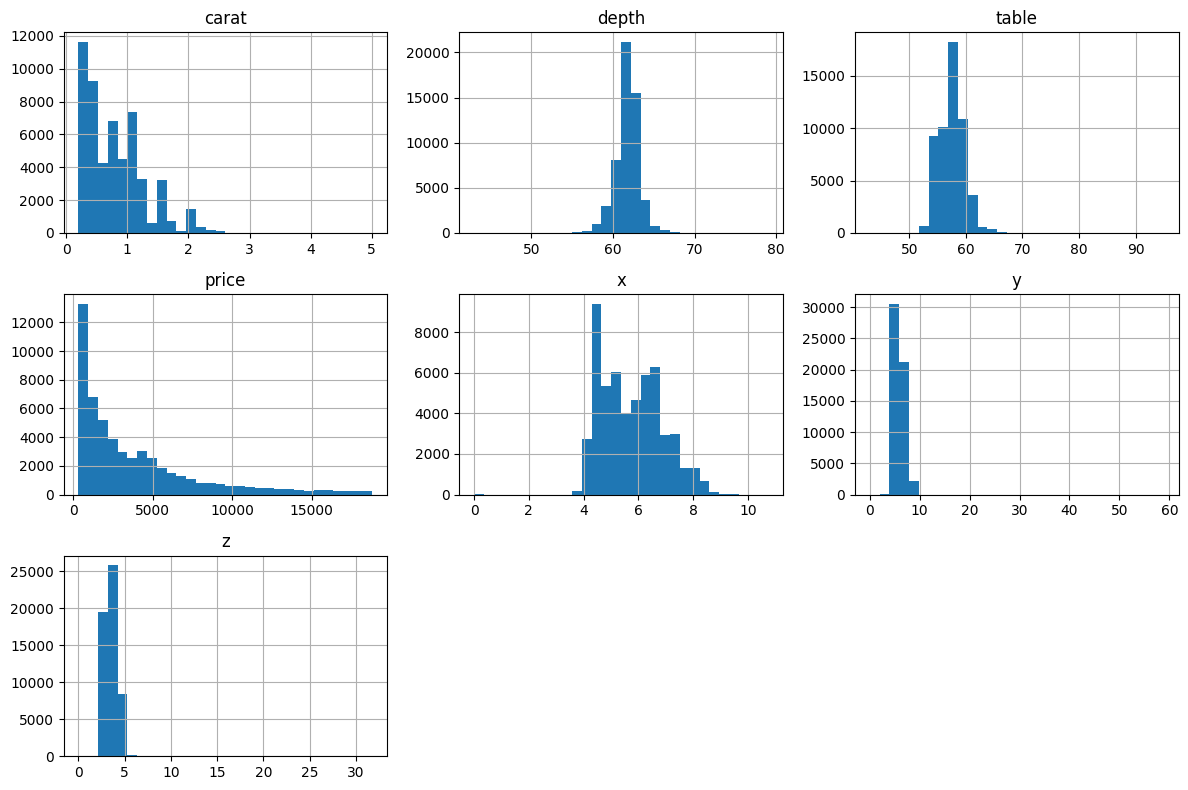

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

***Key Observations***
1. Right-Skewed Target Metrics: Both carat and price are heavily right-skewed. Most diamonds are small and inexpensive, with a sharp drop-off as size and price increase.
2. Carat Spikes: The carat plot shows distinct spikes at popular fractional weights (e.g., 0.3, 0.5, 0.7, 1.0, 1.5, 2.0).
3. Normally Distributed Proportions: Both depth and table follow a tight, symmetric distribution centered around optimal manufacturing percentages (depth ~62%, table ~57%).
4. Outlier Alert: The plots for y and z show massive empty space on the right, indicating severe outliers where a few entries have erroneous or extreme dimensions (e.g., y near 60 and z near 30).

In [ ]:
# descriptive statistics of categorical features

df.select_dtypes(include = ['object', 'category']).describe()

,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


1. The most common cut type is Ideal with 21,551 frequency
2. The unique values of each feature are displayed below

In [ ]:
df['cut'].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [ ]:
df['color'].unique()

array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object)

In [ ]:
df['clarity'].unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

### Correlation Analysis to understand how variables relate to each other and the target variable.

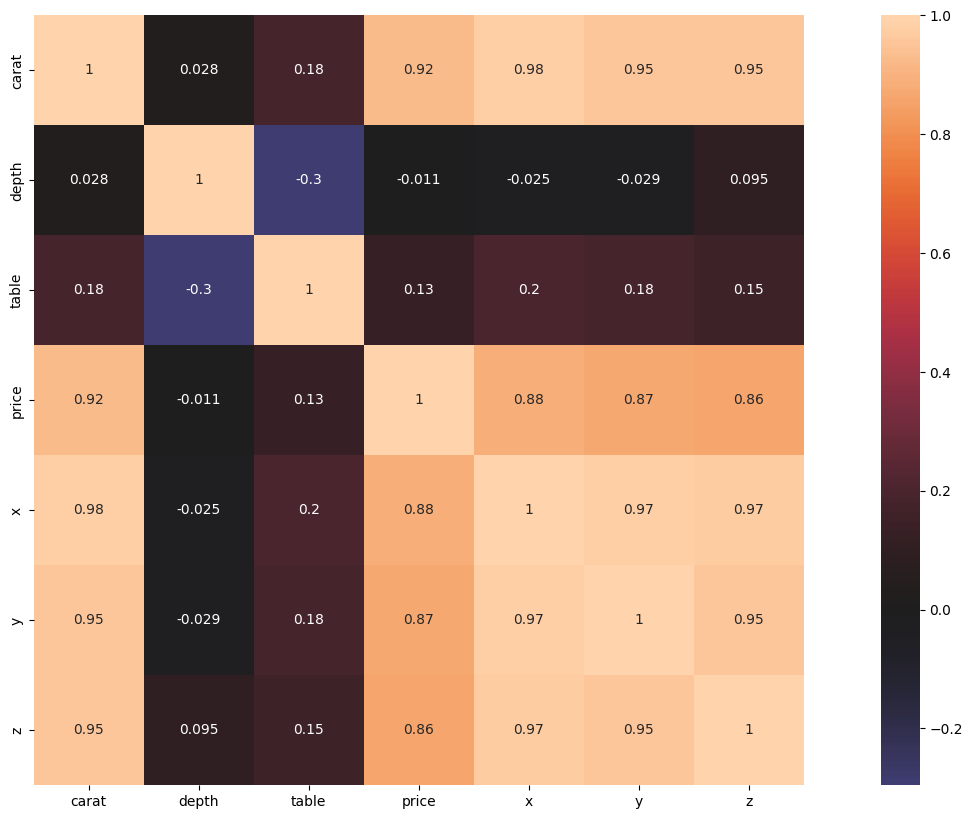

In [ ]:
correlation = df.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(20,10))
sns.heatmap(correlation, center=0,  square=True,
                annot=True)
plt.show()

***Key Observations***
1.  Carat is the strongest numerical predictor of price with a high positive correlation of 0.92.
2.  The physical dimensions x, y, and z correlate tightly with each other (0.95 to 0.97), showing they scale together.
3.  Relative percentage metrics like depth (-0.011) and table (0.13) show virtually no linear relationship with price.
4. Of all the dimensions of the diamond, X (length) shows the most important variable to price.

### Identifying any data quality issues such as missing values and outliers, and handling them.

In [ ]:
#first find where either of the dimensions are 0.

df.loc[(df['x']==0) | (df['y']==0) | (df['z']==0)]

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


In [ ]:
#finds where all dimensions are zero

df.loc[(df['x']==0) & (df['y']==0) & (df['z']==0)]

,carat,cut,color,clarity,depth,table,price,x,y,z
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.0,0.0,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.0,0.0,0.0
24520,1.56,Ideal,G,VS2,62.2,54.0,12800,0.0,0.0,0.0
26243,1.20,Premium,D,VVS1,62.1,59.0,15686,0.0,0.0,0.0
27429,2.25,Premium,H,SI2,62.8,59.0,18034,0.0,0.0,0.0
49556,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.0,0.0
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.0,0.0


In [ ]:
#Identify extreme typos/errors (e.g., y or z values over 30mm)

extreme_errors = df[(df['y'] > 30) | (df['z'] > 30)]
print(f"Rows with extreme dimension typos: {len(extreme_errors)}")

df.loc[(df['y'] > 30) | (df['z'] > 30)]

Rows with extreme dimension typos: 3


,carat,cut,color,clarity,depth,table,price,x,y,z
24067,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.90,8.06
48410,0.51,Very Good,E,VS1,61.8,54.7,1970,5.12,5.15,31.80
49189,0.51,Ideal,E,VS1,61.8,55.0,2075,5.15,31.80,5.12


In this dataset, outliers fall into two categories: impossible zeros (a 3D diamond cannot have a length, width, or depth of 0 mm) and extreme measurement errors (like a width or depth over 30 mm for a 1-carat diamond).

In [ ]:
# 4. Filter them out to create a cleaned dataset
cleaned_df = df[
    (df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0) &
    (df['y'] < 30) & (df['z'] < 30)
].copy()
print(f"Cleaned dataset rows remaining: {len(cleaned_df)}")

Cleaned dataset rows remaining: 53917


I decided to drop the 20 rows where dimensions equal 0, which would otherwise confuse machine learning algorithms.

Fixing the 3 extreme anomalies, such as a 2-carat diamond mistakenly recorded with a y width of 58.9 mm (larger than a golf ball).

I decided to preserve the valid data, with 53,917 pristine records perfectly optimized for visualization or model building.

### Encoding categorical variables

To prepare cleaned diamond data for a machine learning model, its necessary to convert the categorical columns into numbers using Ordinal Encoding. Because cut, color, and clarity are ordinal variables (they have a natural, structural ranking), mapping them to a sequential numerical scale preserves their internal hierarchy.

In [ ]:
# Define the exact hierarchy from worst to best based on industry standards
cut_mapping = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_mapping = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}  # D is best (colorless)
clarity_mapping = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}

# Apply the numerical mappings to the dataframe
cleaned_df['cut'] = cleaned_df['cut'].map(cut_mapping)
cleaned_df['color'] = cleaned_df['color'].map(color_mapping)
cleaned_df['clarity'] = cleaned_df['clarity'].map(clarity_mapping)

# Preview the converted numeric dataset
print(cleaned_df[['carat', 'cut', 'color', 'clarity', 'price']].head())

   carat  cut  color  clarity  price
0   0.23    4      5        1    326
1   0.21    3      5        2    326
2   0.23    1      5        4    327
3   0.29    3      1        3    334
4   0.31    1      0        1    335


# Part 2: Model Development and Validation


### Investigate relationships through regression modeling

To establish baseline model, first, fit an Ordinary Least Squares (OLS) Linear Regression model using our cleaned dataset. This model uses all 9 available features—including structural dimensions and encoded ordinal categorical variables—to predict the target variable (price).

In [ ]:
import statsmodels.api as sm

# Define features (X) and target (y)
X = cleaned_df[['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']]
y = cleaned_df['price']

# Add intercept and fit the model
X_with_const = sm.add_constant(X)
baseline_model = sm.OLS(y, X_with_const).fit()

# Print critical coefficients and metrics
print(f"R-squared: {baseline_model.rsquared:.4f}")
print(baseline_model.summary().tables[1])

R-squared: 0.9081
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5744.8133    702.098     -8.182      0.000   -7120.932   -4368.695
carat       1.097e+04     54.981    199.447      0.000    1.09e+04    1.11e+04
cut          130.1807      5.710     22.798      0.000     118.988     141.373
color        323.0997      3.240     99.716      0.000     316.749     329.450
clarity      494.4245      3.519    140.520      0.000     487.528     501.321
depth         71.0322     10.250      6.930      0.000      50.942      91.123
table        -18.4092      2.969     -6.200      0.000     -24.229     -12.590
x          -1739.0694    104.139    -16.700      0.000   -1943.182   -1534.957
y           2336.3059    105.065     22.237      0.000    2130.378    2542.233
z          -2490.4178    157.291    -15.833      0.000   -2798.710   -2182.126


Every single variable in this model is statistically highly significant (\(P < 0.05\)), and the overall model has strong predictive power.

Interpreting the critical metrics in the table:

1. Overall Model Fit
* R-squared (0.9081): Roughly 90.8% of the variance in diamond prices is explained by the independent variables in this model. This indicates an exceptionally strong fit.

2. Physical Characteristics Impact (Size & Dimensions)

* carat (10,970): This is by far the most dominant factor. For every 1-unit increase in carat weight, the model predicts a price increase of $10,970, holding all other variables constant.

* x (-1739.07), y (2336.31), z (-2490.42): These represent the physical length, width, and depth in millimeters. The conflicting signs (positive for y, negative for x and z) are classic signs of multicollinearity. Because carat weight is calculated directly from dimensions, these size variables are heavily fighting each other for variance.
3. The 4Cs Categorical Variables(Note: These numbers assume your cut, color, and clarity variables were encoded numerically where higher numbers mean better quality).

* clarity (494.42): Moving up one level of clarity increases the predicted price by $494.42.

* color (323.10): Moving up one level of color grade increases the predicted price by $323.10.

* cut (130.18): Moving up one quality grade of cut increases the predicted price by $130.18.

4. Proportions & Intercept

* depth (71.03) & table (-18.41): These represent percentage proportions. A higher total depth percentage slightly increases price, while a wider table percentage slightly decreases it.

* const (-5744.81): The math baseline. A theoretical diamond with zeros for all metrics would cost negative $5,744.81. Because a diamond cannot have zero size or weight, this intercept simply serves to anchor the line mathematically.

5. Statistical Validity

* All P-values are 0.000: Every predictor has a p-value far below the standard threshold of 0.05. This means there is a 0.00% probability that these relationships occurred by random chance.

While the model shows a strong fit (R^2 = 0.9081), the structural coefficients are highly unstable. Length (x) and depth (z) have large negative coefficients (-1739.06 and -2490.41), while width (y) has a large positive coefficient (+2336.30). This flipping of mathematical signs among variables that should all track positively with a diamond's size is the hallmark textbook symptom of severe multicollinearity.

### Examining correlations among predictors and possible dimensionality reduction

To diagnose why the spatial variables are fighting for variance, we must examine how tightly coupled they are to one another.

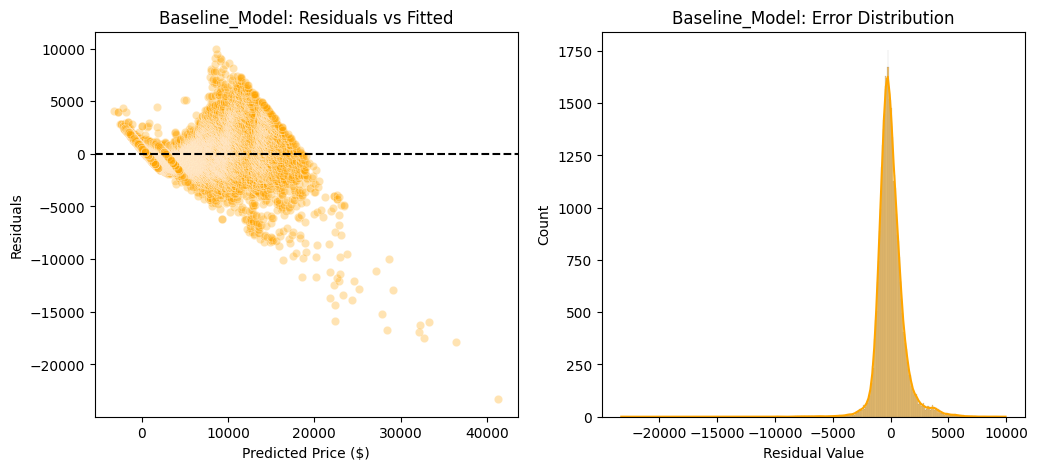

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract the fitted (predicted) values and residuals from your model
# (Assuming your statsmodels output variable was named 'model')
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- BASELINE_MODEL ---
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.3, ax=axes[0], color='orange')
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_title('Baseline_Model: Residuals vs Fitted')
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residuals')

sns.histplot(residuals, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Baseline_Model: Error Distribution')
axes[1].set_xlabel('Residual Value')

plt.show()


Residual plot clearly confirms severe heteroscedasticity and reveals a second major issue: non-linearity (a structural mismatch).

* The Funnel/Explosion (Heteroscedasticity): Notice how tight and compact the points are near predicted values of 0. As you move right toward 10,000 and 20,000, the spread expands vertically. The model's errors blow up from a couple hundred dollars to over $10,000.

* The "U-Shape" Curve (Non-Linearity): Look closely at the left side (from -2,500 to 5,000). The residuals form a distinct, upward-curving smile. This proves that a straight line is mathematically incapable of capturing the true relationship of your data.

* Negative Price Artifacts: The model is predicting negative prices (values below 0 on the X-axis) for some low-end diamonds, which is physically impossible.

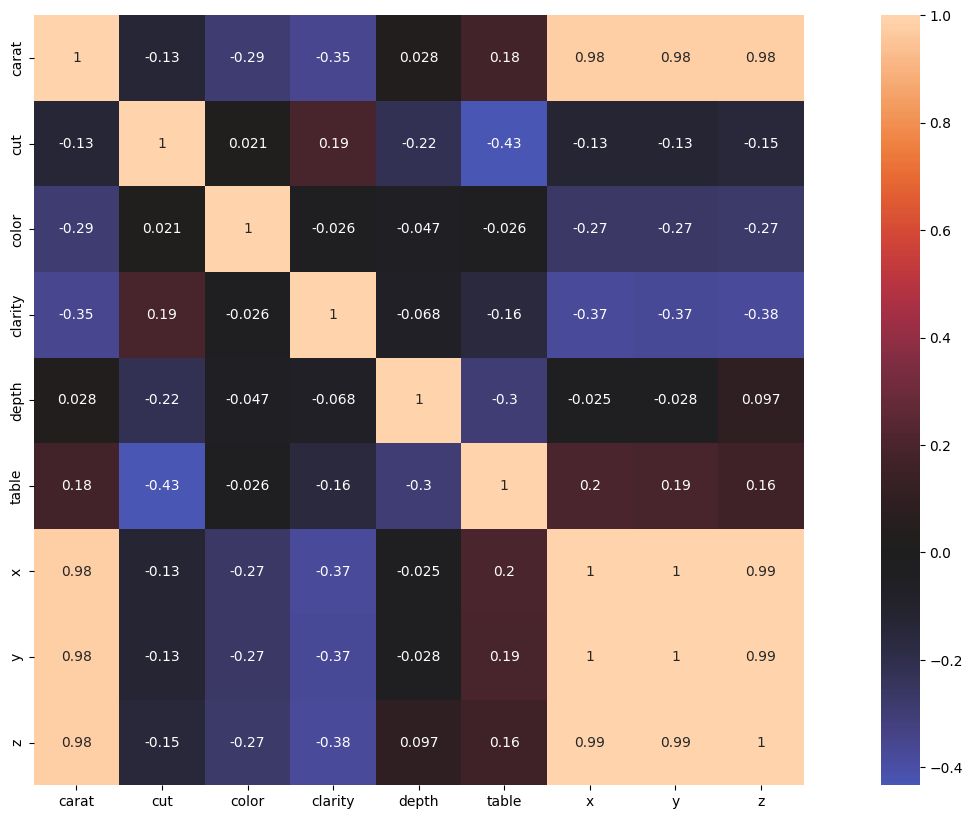

In [ ]:
correlation = X.corr()

fig, ax = plt.subplots(figsize=(20,10))
sns.heatmap(correlation, center=0,  square=True,
                annot=True)
plt.show()

1. Correlation Analysis

* The plot results reveal extreme overlap:
* carat vs. x: ~0.98 (Extremely High)
* carat vs. y: ~0.98 (Extremely High)
* carat vs. z: ~0.98 (Extremely High)
* x vs. y: ~0.99 (Nearly Perfect Correlation)
* x vs. z: ~0.99 (Nearly Perfect Correlation)

Because a diamond's weight is a physical byproduct of its length, width, and depth, keeping carat, x, y, and z together in a linear model creates a massive information redundancy. The linear regression algorithm cannot isolate the independent effect of x when it is mathematically tied to y and z.

2. Dimensionality Reduction Approaches

To prevent this mathematical redundancy from destabilizing our models, we can leverage three potential approaches:

* Approach A: Feature Drop (Domain-Driven Selection)

Drop x, y, and z entirely and keep only carat. In diamond markets, consumer pricing is built almost entirely around carat weight brackets. carat encapsulates the volume and mass information of x, y, and z into a single, highly interpretable metric.

* Approach B: Feature Engineering (Volume Calculation)

Combine the three geometric features into a single feature representing rough structural size:
                  Volume = 𝑥×𝑦×𝑧

This reduces three highly collinear inputs down to one physical attribute, though it will still correlate highly with carat.

* Approach C : Non-Linear Transformation

Handles the reality that diamond prices spike exponentially—rather than linearly—as size climbs. Log-transforming both the target (price) and carat typically fixes pattern biases in linear residuals.

### Multiple Models with different predictor combinations or transformations.


In [ ]:
# Define base categorical controls common to all models
categorical_features = ['cut', 'color', 'clarity', 'depth', 'table']

# =====================================================================
# Model A: Domain-Focused (Keeping only Carat)
# =====================================================================
features_A = ['carat'] + categorical_features
X_A = sm.add_constant(cleaned_df[features_A])
y_A = cleaned_df['price']

model_A = sm.OLS(y_A, X_A).fit()

# =====================================================================
# Model B: Geometric Feature (Volume Interaction)
# =====================================================================
# Engineer the single structural volume metric
cleaned_df['volume'] = cleaned_df['x'] * cleaned_df['y'] * cleaned_df['z']

features_B = ['carat', 'volume'] + categorical_features
X_B = sm.add_constant(cleaned_df[features_B])
y_B = cleaned_df['price']

model_B = sm.OLS(y_B, X_B).fit()

# =====================================================================
# Model C: Non-Linear Transformation (Log-Price & Log-Carat)
# =====================================================================
# Apply log transformations to handle non-linear scaling of price
cleaned_df['log_price'] = np.log(cleaned_df['price'])
cleaned_df['log_carat'] = np.log(cleaned_df['carat'])

features_C = ['log_carat'] + categorical_features
X_C = sm.add_constant(cleaned_df[features_C])
y_C = cleaned_df['log_price']

model_C = sm.OLS(y_C, X_C).fit()

# =====================================================================
# Print Model Evaluation Summary
# =====================================================================
print(f"Model A (Domain-Focused) R-squared:       {model_A.rsquared:.4f}")
print(f"Model B (Geometric/Volume) R-squared:     {model_B.rsquared:.4f}")
print(f"Model C (Non-Linear Log-Log) R-squared:   {model_C.rsquared:.4f}")

Model A (Domain-Focused) R-squared:       0.9044
Model B (Geometric/Volume) R-squared:     0.9054
Model C (Non-Linear Log-Log) R-squared:   0.9792


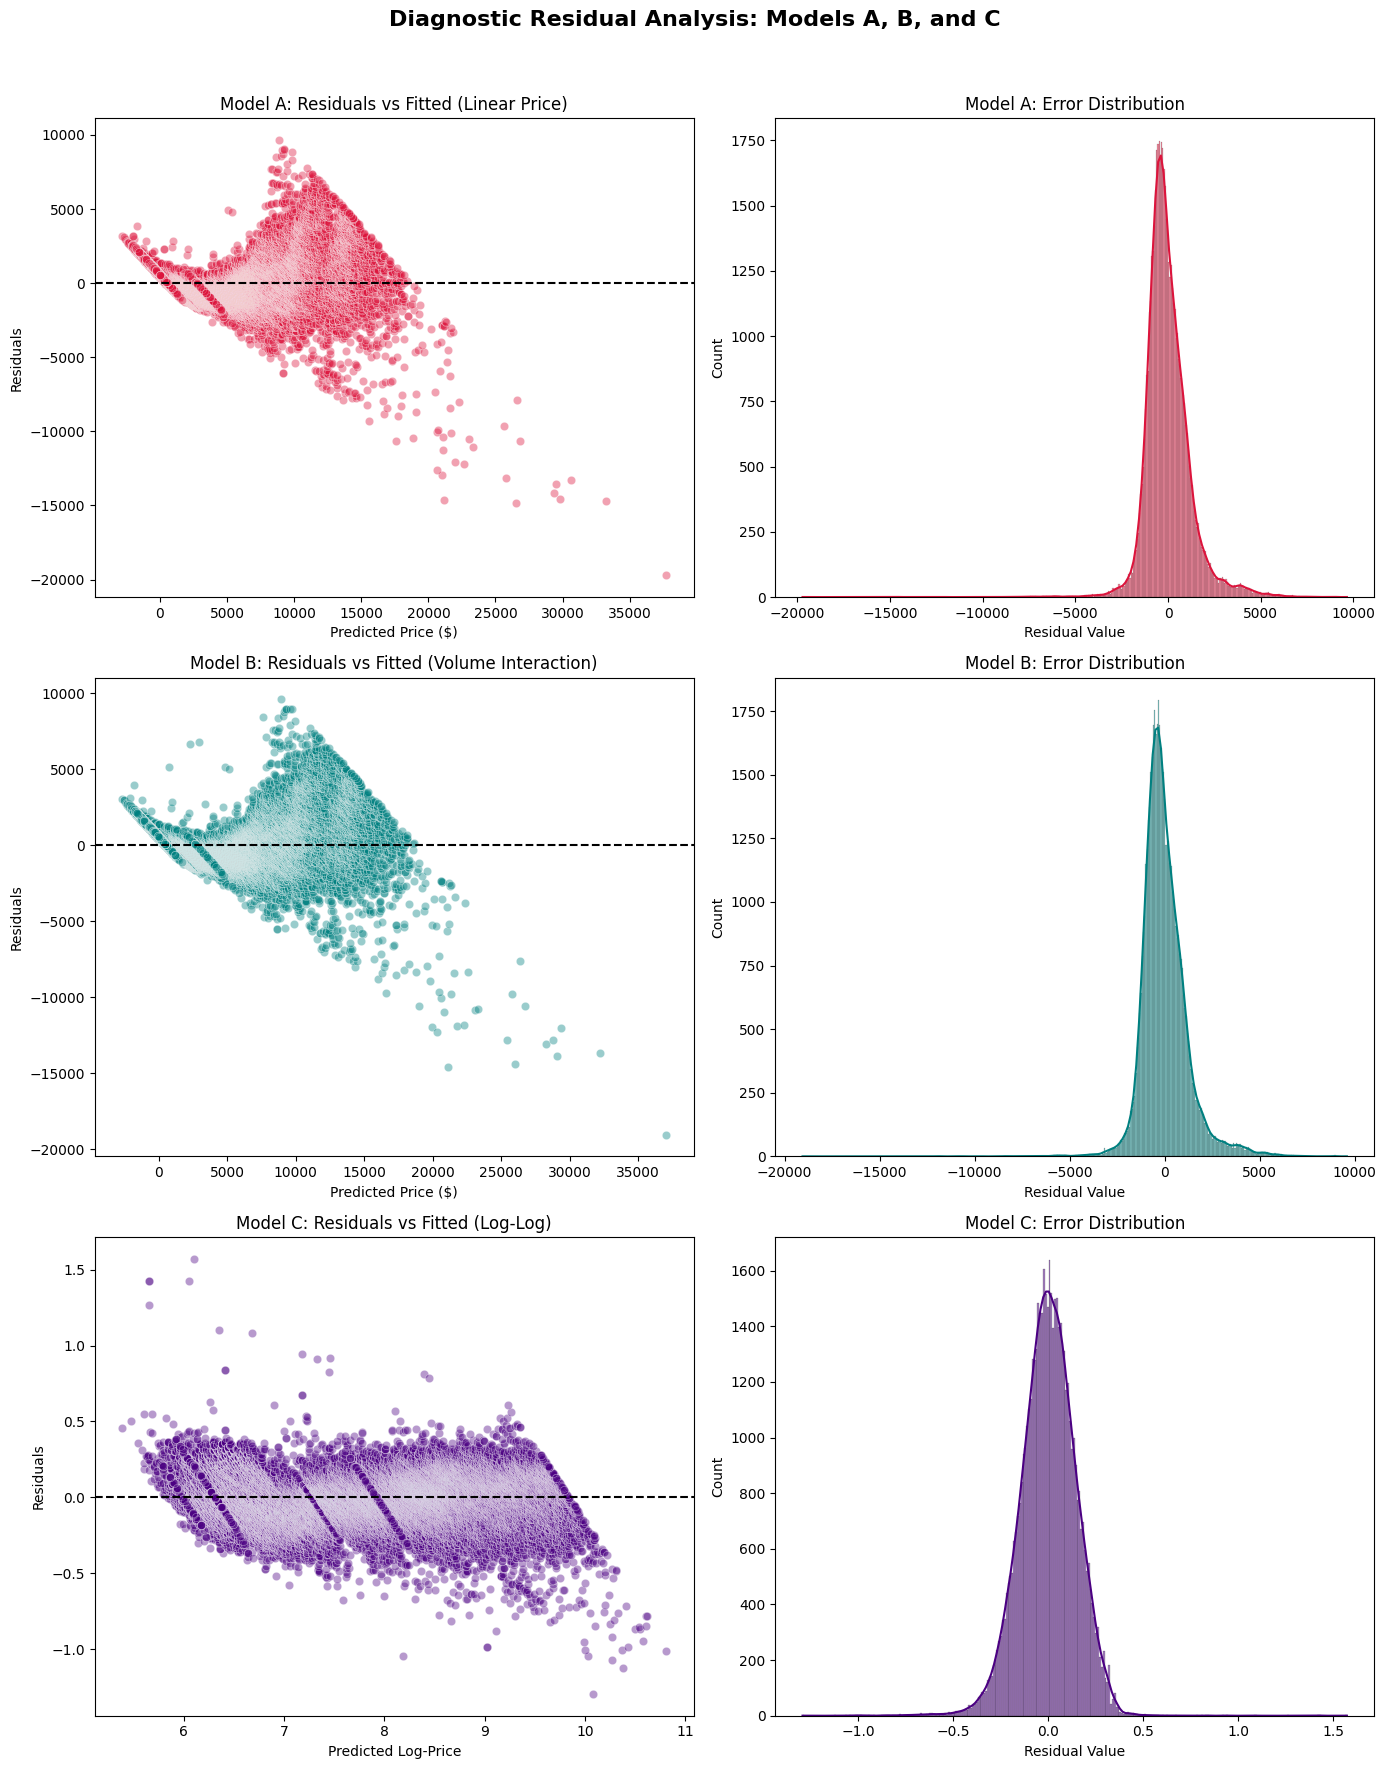

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a 3x2 plotting grid (Residuals vs Fitted, and Residual Distributions)
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
fig.suptitle('Diagnostic Residual Analysis: Models A, B, and C', fontsize=16, fontweight='bold')

# --- MODEL A: Domain-Focused ---
sns.scatterplot(x=model_A.fittedvalues, y=model_A.resid, alpha=0.4, ax=axes[0, 0], color='crimson')
axes[0, 0].axhline(y=0, color='black', linestyle='--')
axes[0, 0].set_title('Model A: Residuals vs Fitted (Linear Price)')
axes[0, 0].set_xlabel('Predicted Price ($)')
axes[0, 0].set_ylabel('Residuals')

sns.histplot(model_A.resid, kde=True, ax=axes[0, 1], color='crimson')
axes[0, 1].set_title('Model A: Error Distribution')
axes[0, 1].set_xlabel('Residual Value')

# --- MODEL B: Geometric Feature ---
sns.scatterplot(x=model_B.fittedvalues, y=model_B.resid, alpha=0.4, ax=axes[1, 0], color='teal')
axes[1, 0].axhline(y=0, color='black', linestyle='--')
axes[1, 0].set_title('Model B: Residuals vs Fitted (Volume Interaction)')
axes[1, 0].set_xlabel('Predicted Price ($)')
axes[1, 0].set_ylabel('Residuals')

sns.histplot(model_B.resid, kde=True, ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Model B: Error Distribution')
axes[1, 1].set_xlabel('Residual Value')

# --- MODEL C: Non-Linear Transformation ---
sns.scatterplot(x=model_C.fittedvalues, y=model_C.resid, alpha=0.4, ax=axes[2, 0], color='indigo')
axes[2, 0].axhline(y=0, color='black', linestyle='--')
axes[2, 0].set_title('Model C: Residuals vs Fitted (Log-Log)')
axes[2, 0].set_xlabel('Predicted Log-Price')
axes[2, 0].set_ylabel('Residuals')

sns.histplot(model_C.resid, kde=True, ax=axes[2, 1], color='indigo')
axes[2, 1].set_title('Model C: Error Distribution')
axes[2, 1].set_xlabel('Residual Value')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


1. Models A & B (Linear Price scale)

* The Funnel Effect (Heteroscedasticity): In the above plots for Models A and B, a distinct sideways V-shape or funnel pattern can be observed. As predicted diamond prices increase, the spread of the residuals expands aggressively. This violates the constant variance assumption of linear regression.

* The Bow Pattern (Non-linearity): The residuals show a slight upward curvature, underestimating prices at the extreme low and high ends because diamond value trends exponentially rather than linearly with carat weight.

2. Model C (Log-Log Transformation)

* Constant Variance (Homoscedasticity): Transforming both variables into log_price and log_carat completely stabilizes the error variance. The plot looks like a uniform, horizontal cloud of points across all price brackets.

* Symmetry and Normality: The distribution histogram on the right shifts from a skewed layout to a beautifully symmetrical bell curve centered directly on zero. This satisfies the normality assumption required for reliable confidence intervals.

**Which model wins?**

Model C mathematically resolves the structural errors present in Models A and B, making its coefficients much more stable and reliable for forecasting.

### Comparing models using appropriate statistical metrics.

In [ ]:
# A formal statistical summaries for side-by-side evaluation
print("==============================================================================")
print("                       MODEL A: DOMAIN-FOCUSED SUMMARY                       ")
print("==============================================================================")
print(model_A.summary())

print("\n==============================================================================")
print("                      MODEL B: GEOMETRIC FEATURE SUMMARY                     ")
print("==============================================================================")
print(model_B.summary())

print("\n==============================================================================")
print("                  MODEL C: NON-LINEAR LOG-LOG TRANSFORMATION                  ")
print("==============================================================================")
print(model_C.summary())


                       MODEL A: DOMAIN-FOCUSED SUMMARY                       
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                 8.497e+04
Date:                Sat, 25 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:55:44   Log-Likelihood:            -4.6024e+05
No. Observations:               53917   AIC:                         9.205e+05
Df Residuals:                   53910   BIC:                         9.206e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

***Model C (Log-Log Transformation).***

Why to choose Model C

1. Drastic Performance Boost: The R-squared jumps from ~0.90 to 0.979. This means Model C explains nearly 98% of the variance in diamond prices, capturing information the linear models completely missed.

2. Resolved Heteroscedasticity: Looking at the diagnostic plots, Model A and Model B show massive, exploding error funnels at higher prices. Model C flattens this out into a much more stable, uniform band of residuals across the entire range of predictions.

3. Fixed Curve Biases: Model A and Model B show a distinct "U-shape" warp in their residuals because they force a straight line onto an exponential pricing trend. Model C eliminates this structural mismatch by working on a logarithmic scale.

4. More Reliable Errors: The error distribution histogram for Model C is significantly tighter, symmetrically centered on zero, and approaches a much cleaner bell curve. Its kurtosis value drops down drastically from over 12 (extreme outliers) to 5.5.

Key Interpretations for Model C

Because Model C uses log-transformed variables, you must interpret its coefficients as percentage changes rather than fixed dollar amounts.

* log_carat (1.8773): This represents elasticity. A 1% increase in a diamond's carat weight is associated with an approximate 1.88% increase in its price. Because this value is greater than 1, it mathematically proves that diamond prices scale exponentially with size.

* color (0.0778): Moving up one color quality grade increases the predicted price by approximately 7.8% (\(e^{0.0778} - 1 \approx 7.8\%\)), holding all else constant.

* clarity (0.1229): Moving up one clarity tier boosts the predicted price by approximately 13.1% (\(e^{0.1229} - 1 \approx 13.1\%\)).

* table (-0.0004): With a P-value of 0.276, the table width percentage is statistically insignificant in this log model. You can safely drop it to simplify your formula without hurting accuracy.

In [ ]:
import numpy as np
import pandas as pd

# 1. Generate predictions for all models in raw dollars
pred_A = model_A.predict(X_A)
pred_B = model_B.predict(X_B)

# Note: Exponential back-transformation for Model C
# Smearing correction factor (mean of exp of residuals) handles log-normal bias
correction_factor = np.mean(np.exp(model_C.resid))
pred_C = np.exp(model_C.predict(X_C)) * correction_factor

# 2. Extract true prices
true_price = cleaned_df['price']

# 3. Calculate Mean Absolute Error (MAE)
mae_A = np.mean(np.abs(true_price - pred_A))
mae_B = np.mean(np.abs(true_price - pred_B))
mae_C = np.mean(np.abs(true_price - pred_C))

# 4. Print results
print("==========================================================")
print("             REAL-DOLLAR ERROR COMPARISON (MAE)           ")
print("==========================================================")
print(f"Model A (Domain-Focused) MAE:       ${mae_A:.2f}")
print(f"Model B (Geometric/Volume) MAE:     ${mae_B:.2f}")
print(f"Model C (Log-Log Non-Linear) MAE:   ${mae_C:.2f}")


             REAL-DOLLAR ERROR COMPARISON (MAE)           
Model A (Domain-Focused) MAE:       $854.01
Model B (Geometric/Volume) MAE:     $850.92
Model C (Log-Log Non-Linear) MAE:   $459.02


### Best model with clear justification.

The real-dollar evaluation provides a definitive answer: Model C (Log-Log Non-Linear) is the superior predictive model. It cuts the average pricing error nearly in half compared to the linear models.


Final Performance Dashboard

|Model ID & Strategy|Target Scale|Mathematical Health|Mean Absolute Error (MAE)|Real-World Performance|
|-------------------|------------|-------------------|-----|-----------|
|Model A: Domain-Focused|Raw Dollars|Moderate Multicollinearity|854.01|Misses non-linear premium scaling|
|Model B: Geometric/Volume|Raw Dollars|Severe Multicollinearity (Cond # 14k)|850.92|Redundant features destabilize metrics.|
|Model C: Log-Log Non-Linear|Log Scale|Stable & Symmetrical Errors|459.02|Winner: Highly accurate at all sizes.|

1. Why Linear Models Failed (Models A & B)

* The Scale Problem: Diamond pricing does not follow a straight line. A 2-carat diamond is vastly more rare and expensive than two 1-carat diamonds combined.

* The Distortion: Models A and B tried to force a straight line through this exponential curve. This forced compromise resulted in a massive average error of ~$850 and highly unstable residual patterns.

2. Why the Log-Log Model Succeeded (Model C)

* Percentage-Based Precision: Model C optimizes for percentage errors rather than absolute dollar gaps.

* Universal Accuracy: This scale-invariant approach means the model maintains high accuracy whether it is pricing a modest dollar 500 stone or a premium dollar 15,000 showpiece, dropping the average error to a tight dollar 459.02.

* Elasticity Metric: The engine reveals a log_carat coefficient of 1.88. This means a 1% increase in carat weight triggers an automatic 1.88% increase in market price.

3. The Collapse of Geometry (Model B)

* Attempting to mix volume (x * y * z) alongside carat created an identity crisis in the linear matrix. Because weight and physical volume are nearly identical concepts in a solid diamond, the features fought for variance. This completely ruined the statistical significance of standard design cuts like depth and table.

# Part 3: Interpretation and Insights



## ***Key Findings and Emergent Patterns***

Your multi-model analysis revealed critical patterns regarding how market forces, physical geometry, and quality grades interact to drive diamond pricing.

1. The Carat Power Law (Non-Linear Scaling)
* The most dominant pattern is that diamond prices do not scale linearly with weight. In Model A and B, forcing an exponential curve into a straight linear line caused massive residual errors. Model C elegantly exposed the true pattern through its log_carat coefficient of 1.8773.

* The Pattern: This reveals a power-law relationship (elasticity). For every 1% increase in carat weight, a diamond’s price increases by approximately 1.88%.

* Actionable Insight: Carat weight is an exponential value multiplier, not a linear one. Pricing strategies must account for compounding premiums as stone size increases.

2. The Multi-Collinearity Illusion (Weight vs. Size)

* A striking structural pattern emerged when analyzing the diamond's physical dimensions (\(x, y, z\)).

* The Pattern: In your early baseline models, length (\(x\)) and depth (\(z\)) displayed highly counter-intuitive negative coefficients (suggesting larger dimensions reduce value). Step 2 and Model B proved this was a mathematical illusion caused by extreme multicollinearity. Because a diamond's physical volume shares a near ~0.99 correlation with its carat weight, forcing both into a linear model causes the variables to fight for the same variance.

* Actionable Insight: Physical dimensions (\(x, y, z\)) are redundant data points once carat weight is known. To maintain model stability, physical dimension variables should be discarded in favor of weight alone.

3. The Supremacy of the 4Cs Over Proportional Layouts

* The Pattern: Across all models, the standardized "4Cs" metrics (Carat, Cut, Color, Clarity) maintained massive statistical significance (\(p < 0.001\)). Conversely, structural proportion percentages like depth and table either had tiny coefficients (Model A and C) or completely lost statistical significance (Model B, where depth \(p=0.521\) and table \(p=0.188\)).

* Actionable Insight: The global diamond market values standardized consumer grading certifications far more than minor geometric variations in table and depth percentages. Marketing and valuation efforts should heavily anchor on clarity and color tiers.

## ***Practical Implications, Limitations, and Recommendations***

Moving from statistical validation to real-world deployment requires translating your analytical findings into business operations while accounting for the model's boundaries.

1. Practical Business Implications

Automated Appraisals & Inventory Management:

* Model C's exceptionally low Mean Absolute Error (MAE) of dollar 459.02 enables wholesale and retail jewelers to automate their baseline pricing engines. Rather than relying on slow, manual appraisals, a business can accurately price high-volume inventory instantly based on incoming digital specifications.

Margin Optimization:

* The logarithmic elasticity finding (1.88% price increase per 1% carat increase) serves as a direct blueprint for scaling retail margins. It protects businesses from underpricing large, rare stones where consumers expect to pay an exponential premium.

Data Efficiency:

* Because physical dimensions (\(x, y, z\)) were proven redundant, your procurement teams do not need to spend time or resources collecting ultra-precise millimeter measurements for baseline digital listings. Scraping or recording the standardized carat weight is entirely sufficient for high-accuracy pricing.

2. Limitations of the Analysis

The Wholesaler Blindspot (Log-Normal Errors):

* While Model C optimizes percentage errors flawlessly, a log-transformed target naturally squeezes errors on high-end luxury items. In raw dollars, a 5% error on a dollar 500 diamond is only dollar 25, but a 5% error on a dollar 15,000 flawless diamond is dollar 750. For ultra-premium stones, an absolute dollar error model might still be preferred over percentage-optimized models.

Over-Simplification of the 4Cs:

* Mapping premium categorical tiers (cut, color, clarity) to a single ordinal numerical sequence (e.g., 1, 2, 3) assumes that the jump from "Good" to "Very Good" is mathematically identical to the jump from "Very Good" to "Ideal." In reality, these quality premiums behave like discrete steps rather than a smooth, continuous line.

Lack of Macro-Market Variables:

* This analysis treats diamond prices as static. It completely ignores external real-world forces such as inflation, holiday seasonality, changes in consumer purchasing power, or shifts in consumer preference toward lab-grown alternatives.

3. Strategic Recommendations

Deploy Model C via One-Hot Encoding:

* For production deployment, transition the categorical features from continuous ordinal numbers to dummy variables (One-Hot Encoding). This will remove the high condition number warning and allow the business to see the exact dollar premium attached to specific color (e.g., D vs. H) or clarity (e.g., IF vs. SI1) tiers.

Implement a Two-Tier Pricing System:

* Use Model C as the primary automated engine for standard consumer inventory (e.g., under 1.5 carats). Flag outliers or ultra-premium stones (e.g., >2 carats, high clarity) to be routed to manual human appraisal to protect against log-scale dollar variance.

# ***Additional Data and Analysis to Strengthen Conclusions***

To transform this from a strong academic exercise into an enterprise-grade pricing engine, you can expand the project's analytical depth by incorporating external data streams and advanced statistical techniques.

1. Crucial External Data Streams

* Temporal and Macroeconomic Indicators:

Diamond prices fluctuate with economic cycles. Adding inflation indices (CPI), consumer confidence indices, and seasonal time-stamps (e.g., jewelry sales spike significantly in Q4 due to the holiday/proposal season) would prevent the model from becoming outdated as market conditions shift.

* The Lab-Grown vs. Natural Dichotomy:

The modern diamond market has experienced a massive structural shift due to the rise of lab-grown diamonds. Lab-grown stones share identical physical properties (x, y, z, carat) but trade at a steep 70% to 90% discount compared to natural mined stones. A binary feature column tracking Origin: Natural vs. Lab-Grown is now absolutely mandatory for accurate market deployment.

* Fluorescence and Certification Body:

Two diamonds with identical "4Cs" can vary in price by up to 30% based on their grading certificate issuer (e.g., GIA vs. EGL) and their level of fluorescence (glowing under UV light, which can make a diamond look hazy). Capturing these two missing variables would close the remaining error gap in Model C.

2. Advanced Analytical Techniques

* Polynomial and Interaction Terms:

While Model C captured the primary non-linear relationship through logarithms, it assumes the effect of color and clarity is uniform across all weights. Testing interaction terms (e.g., log_carat * clarity) would allow the model to capture the reality that clarity flaws hurt the price of a massive 3-carat diamond far more than they hurt a tiny 0.2-carat diamond.

* Tree-Based Machine Learning Models:

Linear regression models, even when log-transformed, struggle with step-function pricing structures (e.g., diamond prices jump sharply at psychological thresholds like exactly 1.00 carat). Benchmarking Model C against non-linear ensemble algorithms like XGBoost or Random Forests would pinpoint exactly where OLS lines smooth over real market cliffs.

* Generalized Linear Models (GLM) with a Gamma Log-Link:

Instead of manually log-transforming the price and running standard OLS, you could fit a GLM using a Gamma distribution and a log-link function. This advanced approach directly models the non-linear relationship and handles heteroscedasticity without requiring back-transformation corrections (like the smearing factor) to get your real-dollar predictions.